# STUAART: Validation pipeline

This notebook is designed to process, synchronize, and validate time-series mass data collected from the **STUAART** automated cage system. The primary goal is to transform raw CSV data into a continuous, analyzed dataset while assessing the system's accuracy against manual ground-truth measurements.

The script follows a structured workflow to ensure data integrity:
1.  Environment Setup: Loading dependencies (`NumPy`, `Pandas`, `Matplotlib`, etc.).
2.  Configuration: Setting directory paths and inputting manual ground-truth data.
3.  Synchronization: Mounting Google Drive and aligning experimental timestamps.
4.  Extraction: Aggregating daily fragmented CSV files into a single continuous array.
5.  Metrics Calculation:
    * MAE & RMSE: Quantifying weighing accuracy.
    * SNR & CV: Measuring signal noise and precision.
    * Pearson Correlation ($r$): Validating trend sensitivity and ground-truth alignment.
    * Completeness: Checking for hardware uptime and potential data loss.
6.  Visualization: Generating a 1:1 validation scatter plot to detect calibration biases.

## Quick Start

In Cell 2,
1. Ensure your data is organized in the specified `project_directory`.
2. If you want to save the values of the metrics, set `save_data` to True and modify `saved_filename` to your preferred name.
3.  Update `delta_t` to define the time window in which the metrics are computer around the real mass.  
4.  Update the `manual_mass` list with your reference measurements: `(day, time, mass_in_grams)`.

Finally, run all cells to generate the validation report and save the processed metrics.

In [74]:
import numpy as np
from numpy._core.numeric import indices
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path

# Configuration and Manual Ground Truth

This cell is used to define global variables, file paths, and experimental parameters. This section includes the manual_mass list, which serves as the ground truth (reference measurements) to validate the automated system.

In [75]:
# Change these variables
project_directory = "/content/drive/My Drive/DCCM_Lab/labdata/vpineaunoel/stuaart"
data_path = project_directory + "/20260730-3MiceInSTUAARTs_5/Pink/RollingMean/"
save_data = True
debug_mode = False
time_is_in_hour = True
time_acquired_with_millis = False
threshold_outliers = 50
sampling_rate = 80
delta_t = 2
saved_filename = "2026.07.30-PinkSTUAART-" + str(delta_t) + "-RollingMean-metrics.csv"

# Add in the list the real mass measurements done during the experiment.
# Format : (day, time, mass)
manual_mass = [
    (1, "13:52", 28.4),
    (1, "16:28", 28.2),
    (2, "10:00", 29.5),
    (2, "16:03", 29.0),
    (3, "10:00", 29.2),
    (4, "10:00", 26.4),
    (4, "15:00", 28.0),
    (5, "8:50", 29.3),
    (5, "12:55", 29.3),
    (6, "8:41", 29.8)
    ]

# Google Drive Integration

This cell mounts Google Drive to the Colab environment and set the working directory to the project folder for seamless file access.

In [76]:
from google.colab import drive
drive.mount('/content/drive/')
import os
os.chdir(project_directory)

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


# Data Processing Functions

This cell defines the core logic for the STUAART data pipeline. These functions handle the transition from raw, fragmented CSV files to a synchronized and validated time-series dataset.

- `identify_all_days_of_experiment()`: Scans the data directory to extract dates from filenames and assigns a relative day index (e.g., Day 1, Day 2) to maintain a chronological sequence.
- `str_to_float_hour()`: Converts standard "HH:MM" or relative float/int timestamps into a decimal format (float) for easier mathematical operations.
- `compute_start_shift()`: Determines the time offset by analyzing the duration of the first data file. This ensures that the data aligns correctly with a 24-hour cycle, regardless of when the experiment started.
- `extract_data_from_all_days()`: The primary aggregation engine. It iterates through all daily files, converts millisecond timestamps to hours, applies the start shift, and concatenates the mass data from multiple scales into a single continuous array.
- `format_manual_mass()`: Synchronizes the manual ground-truth measurements with the script's internal timeline. It handles both date-based and relative day inputs to ensure the validation metrics are calculated at the exact correct moment in the series.
- `sum_data_over_time()`: Sums mass from individual scales at every timepoint to calculate the total mass within the cage environment.
- `compute_sampling_frequency()` :

In [77]:
def identify_all_days_of_experiment(data_path, debug_mode):
  """
  Extracts experiment dates and relative day indices from CSV filenames.

  Args:
      data_path (str): Directory containing .csv files named 'YYYYMMDD-...'.
      debug_mode (bool): If True, prints mapping results.

  Returns:
      tuple: (list of date strings, list of relative day integers).
  """
  files = os.listdir(data_path)
  files.sort()

  dates_of_experiment = []
  relative_days_of_experiment = []

  i = 1
  for file in files: # put in order the dates of the experiments based on the beginning of the CSV file names.
    if file.endswith(".csv"):
      index_first_dash = file.find("-")
      dates_of_experiment.append(file[:index_first_dash])
      relative_days_of_experiment.append(i)
      i += 1

  if debug_mode:
    print("Dates of experiment : ", dates_of_experiment)
    print("Relative days of experiment : ", relative_days_of_experiment)

  return dates_of_experiment, relative_days_of_experiment


def str_to_float_hour(time_str):
  """
  Converts str hour in the format 00:00 to a float value
  """
  hours, minutes = map(int, time_str.split(':'))
  return hours + (minutes / 60.0)


def compute_start_shift(data_path, debug_mode, time_is_in_hour:bool = False):
  """
  Calculates the time offset required to align experimental data with a 24-hour clock.

  Args:
      data_path (str): Directory containing the experimental CSV files.
      debug_mode (bool): If True, prints file paths and the calculated shift.

  Returns:
      float: The start shift in hours to be added to the time series.
  """
  files = os.listdir(data_path)
  files.sort()
  absolute_first_file = data_path + files[0]
  first_data = pd.read_csv(absolute_first_file)
  if time_is_in_hour:
    first_duration = first_data.iloc[-1, 0]
  else:
    first_duration = first_data.iloc[-1, 0] / (1000 * 60 * 60)
  start_shift = (24.0 - first_duration) % 24

  if debug_mode:
    print("Data path : ", data_path)
    print("Path first day : ", absolute_first_file)
    print("Data first day : ", first_data)
    print("Start shift : ", start_shift)

  return start_shift


def extract_data_from_all_days(data_path, start_shift, debug_mode, time_is_in_hour:bool = False, time_acquired_with_millis:bool = True):
  """
  Aggregates mass data from all daily CSV files into a continuous time series.

  Args:
      data_path (str): Path to the folder containing daily data files.
      start_shift (float): Time offset in hours calculated for the first day.
      debug_mode (bool): If True, prints shape and range of the concatenated data.

  Returns:
      tuple: (time_hour array, mass_data array) representing the full experiment.
  """
  all_time_hour = []
  all_mass_data = []

  files = os.listdir(data_path)
  files.sort()
  for file in files:
    if file.endswith(".csv"):
      file_path = data_path + file
      data = np.array(pd.read_csv(file_path))
      time = data[:,0]
    else:
      continue

    if time_is_in_hour:
      current_time_hour = time
    else:
      current_time_hour = time/(1000 * 60 * 60)

    current_mass_data = data[:, 1:]
    if time_acquired_with_millis:
      start_shift = compute_start_shift(data_path=data_path, debug_mode=debug_mode, time_is_in_hour=time_is_in_hour)
      current_time_hour = (start_shift + current_time_hour)

    all_time_hour.append(current_time_hour)
    all_mass_data.append(current_mass_data)

  # all data is contained in time_hour and mass_data after these two lines
  time_hour = np.concatenate(all_time_hour)
  mass_data = np.concatenate(all_mass_data, axis=0)

  if time_acquired_with_millis is False:
    diffs = np.diff(time_hour)
    rollover_next_day = diffs < -12.0
    rollovers = np.concatenate(([False], rollover_next_day))
    days_passed = np.cumsum(rollovers)
    time_hour = time_hour + (days_passed * 24.0)

  if debug_mode:
    print(f"Beginning {time_hour[0]} an end {time_hour[-1]} value of time overall.")
    print("Time_hour : ", time_hour, time_hour.shape)
    print(f"Mass data : {mass_data} {mass_data.shape}")

  return time_hour, mass_data


def format_manual_mass(manual_mass, dates_of_experiment, relative_days_of_experiment, start_shift, debug_mode):
  """
  Synchronizes manual ground-truth measurements with the continuous experimental timeline.

  Args:
      manual_mass (list): List of tuples (day, time, mass) to be synchronized.
      dates_of_experiment (list): List of date strings from filenames.
      relative_days_of_experiment (list): List of sequential day integers.
      start_shift (float): Time offset in hours for the first day.
      debug_mode (bool): If True, prints the formatted timestamps and masses.

  Returns:
      list: Formatted tuples (continuous_time_hour, mass) for system validation.
  """
  if manual_mass is None:
    return None
  else:
    new_manual_mass = []
    for m_day, m_time, m_mass in manual_mass:
      if isinstance(m_day, (int, float)):
        new_day = relative_days_of_experiment[m_day-1]
      elif isinstance(m_day, str):
        new_day = dates_of_experiment.index(m_day) + 1

      if isinstance(m_time, str):
        time_in_float = str_to_float_hour(m_time)
      else:
        time_in_float = m_time + start_shift

      new_time = time_in_float + ((new_day-1) * 24)
      new_manual_mass.append((new_time, m_mass))

  if debug_mode:
    print("Real mass after formatting : ", new_manual_mass)

  return new_manual_mass


def sum_data_over_time(data_per_scale):
  """
  Sum data per time point to obtain the mass measurement over time of the whole cage system (and not only per scale).
  """
  summed_data = np.nansum(data_per_scale, axis=1)
  return summed_data


def compute_sampling_rate(time_in_hours):
	"""
	Computes the sampling rate according to the time array.
	"""
	time_in_seconds = time_in_hours*60*60

	dt = np.diff(time_in_seconds)
	# Compute the average sampling rate
	fs_mean = 1 / np.mean(dt)

	# You can also check the variability:
	fs_std = np.std(1 / dt)

	print(f"Estimated mean sampling rate: {fs_mean:.3f} Hz")
	print(f"Standard deviation of sampling rate: {fs_std:.3f} Hz")
	print(f"Min: {1/np.max(dt):.3f} Hz, Max: {1/np.min(dt):.3f} Hz")

	return fs_mean, fs_std


# Execution of Data Pipeline

After definind all the functions we need, we use them to clean, align, and merge the datasets. This transforms raw, fragmented files into a single continuous time series of total mass (`summed_data`) and a synchronized reference list (`formatted_manual_mass`).

In [78]:
dates_of_experiment, relative_days_of_experiment = identify_all_days_of_experiment(data_path=data_path, debug_mode=debug_mode)
start_shift = compute_start_shift(data_path=data_path, debug_mode=debug_mode, time_is_in_hour=time_is_in_hour)
time_hour, mass_data = extract_data_from_all_days(data_path=data_path, start_shift=start_shift, debug_mode=debug_mode, time_is_in_hour=time_is_in_hour, time_acquired_with_millis=time_acquired_with_millis)
formatted_manual_mass = format_manual_mass(manual_mass=manual_mass, dates_of_experiment=dates_of_experiment, relative_days_of_experiment=relative_days_of_experiment, start_shift=start_shift, debug_mode=debug_mode)
summed_data = sum_data_over_time(data_per_scale=mass_data)
mean_sampling_rate, std_sampling_rate = compute_sampling_rate(time_in_hours=time_hour)

Estimated mean sampling rate: 85.072 Hz
Standard deviation of sampling rate: 14.543 Hz
Min: 0.041 Hz, Max: -1.002 Hz


# Validation Metrics and Performance Analysis

This cell calculate key performance indicators to assess the accuracy and reliability of the automated weighing system:

- **Accuracy:** Mean Absolute Error (MAE) and Root Mean Square Error (RMSE).
  - **MAE**: On average, tells how many grams off the STUAART is compared to the ground truth mass.
  - **RMSE**: While MAE treats all errors equally, RMSE penalizes larger outliers more heavily.
- **Precision/Noise:** Coefficient of Variation (CV) and Signal-to-Noise Ratio (SNR).
  - **CV**: Defines the variation of the data compared to the mean.
  - **SNR**: Characterizes the variation around the mean. A high SNR indicates a lot of noise.
- **Trend Correlation:** Pearson’s $r$ (System sensitivity to mass changes). This measures the linear relationship over the entire timeline. Even if there is a slight offset in accuracy, it confirms the system catches mass loss and gain trends.
- **System Validation ($r$):** The Pearson correlation specifically between **manual ground truth** and **automated readings**. This directly validates that the system accurately reflects the animal's true mass at specific validation points.
- **Reliability (Completeness):** Defines how much data was actually acquired compared to how much should be acquired based on the sampling rate. A robust system stays above 95%.
- **Sampling rate :** The computed sampling rate from the data.  

Finally, it generates a scatter plot of the ground truth mass values vs. the measured mass of the system. The proximity of data points to the 1:1 dashed line visually confirms the system's calibration and identifies potential bias.

time and mass :  13.866666666666667 28.4
time_range :  (11.866666666666667, 15.866666666666667)
time_hour :  [ 13.08698722  13.08698944  13.08699222 ... 128.06329    128.06329306
 128.06329639]
Indices in time range :  [     0      1      2 ... 855798 855799 855800]
The percentage of outliers (threshold = 50) : 5.605158 %.
time and mass :  16.466666666666665 28.2
time_range :  (14.466666666666665, 18.466666666666665)
time_hour :  [ 13.08698722  13.08698944  13.08699222 ... 128.06329    128.06329306
 128.06329639]
Indices in time range :  [ 423899  423900  423901 ... 1656011 1656012 1656013]
The percentage of outliers (threshold = 50) : 2.619561 %.
time and mass :  34.0 29.5
time_range :  (32.0, 36.0)
time_hour :  [ 13.08698722  13.08698944  13.08699222 ... 128.06329    128.06329306
 128.06329639]
Indices in time range :  [5818752 5818753 5818754 ... 7044879 7044880 7044881]
The percentage of outliers (threshold = 50) : 0.016882 %.
time and mass :  40.05 29.0
time_range :  (38.05, 42.05

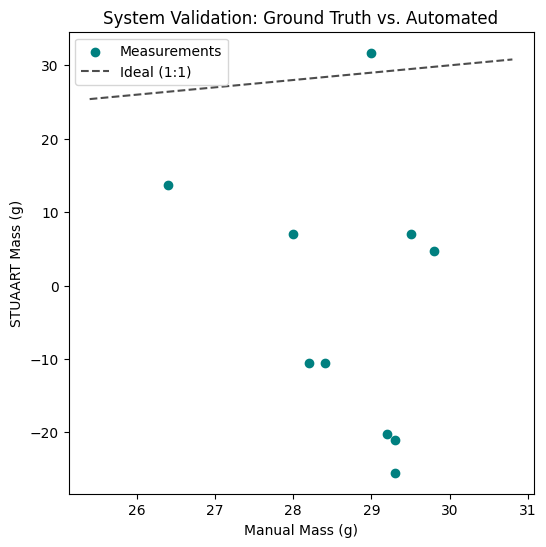

In [79]:
path = Path(data_path)
new_path = path.parent / "Metrics"
new_path.mkdir(parents=True, exist_ok=True)

# Compute MAE, RMSE, CV and SNR
all_MAEs = []
all_CVs = []
all_RMSEs = []
all_SNRs = []
stuaart_measurement_at_manual_time = []
manual_mass_values = []
for m_time, m_mass in formatted_manual_mass:
  print("time and mass : ", m_time, m_mass)
  time_range = (m_time-delta_t, m_time+delta_t)
  print("time_range : ", time_range)
  print("time_hour : ", time_hour)
  indices_in_time_range = np.where((time_hour >= time_range[0]) & (time_hour <= time_range[1]))[0]
  data_in_time_range = summed_data[indices_in_time_range]

  print("Indices in time range : ", indices_in_time_range)

  if indices_in_time_range.shape[0] == 0:
    continue

  stuaart_measurement_at_manual_time.append(np.nanmean(data_in_time_range))
  manual_mass_values.append(m_mass)

  indices_of_outliers = np.where(np.abs(data_in_time_range - m_mass) > threshold_outliers)
  percentage_of_outliers = indices_of_outliers[0].shape[0] / indices_in_time_range.shape[0] * 100
  print(f"The percentage of outliers (threshold = {threshold_outliers}) : {percentage_of_outliers:3f} %.")

  if debug_mode:
    print("DEBUG ------------------------------")
    print(f"m_time : {m_time}, {type(m_time)} and m_mass : {m_mass}, {type(m_mass)}")
    print("Time hour : ", time_hour, time_hour.shape, type(time_hour[0]))
    print("Time range : ", time_range, type(time_range[0]))
    print("Indices in time range : ", indices_in_time_range)
    print("Data in time range : ", data_in_time_range, data_in_time_range.shape)
    print("DEBUG ------------------------------")

  MAE = np.nanmean(np.abs(data_in_time_range - m_mass))
  all_MAEs.append(MAE)
  CV = (np.nanstd(data_in_time_range) / np.nanmean(data_in_time_range)) * 100
  all_CVs.append(CV)
  RMSE = np.sqrt(np.nanmean((data_in_time_range - m_mass)**2))
  all_RMSEs.append(RMSE)
  SNR = np.nanmean(data_in_time_range) / np.nanstd(data_in_time_range)
  all_SNRs.append(SNR)

print("A good MAE is close to 0 g.")
print(f"Mean Absolute Error (MAE) : {np.mean(all_MAEs):3f} computed from {all_MAEs}.")
print("A good CV is typically < 1-2 %.")
print(f"Coefficient of variation (CV) : {np.mean(all_CVs):3f} computed from {all_CVs}.")
print("A good RMSE is close to 0 g.")
print(f"Root Mean Square Error (RMSE) : {np.mean(all_RMSEs):3f} computed from {all_RMSEs}.")
print("A high SNR indicates a lot of noise.")
print(f"Signal-to-noise ratio (SNR) : {np.mean(all_SNRs):3f} computed from {all_SNRs}.")

# Compute Pearson's
matrix = np.corrcoef(time_hour, summed_data)
corr = matrix[0,1]

print("A Pearson's correlation close to 1.0 indicates the system catches mass trends well.")
print(f"Pearson's correlation (r) : {corr:3f}")

# Pearson correlation between manual truth and automated measurement
validation_matrix = np.corrcoef(manual_mass_values, stuaart_measurement_at_manual_time)
r_validation = validation_matrix[0, 1]

print(f"System Validation Correlation (r): {r_validation:3f}")

# Compute completeness/Sparsity
total_experimental_time_hour = time_hour[-1] - time_hour[0]
N_total = sampling_rate * 3600 * total_experimental_time_hour
N_actual = summed_data.shape[0]

completeness = N_actual/N_total * 100

print("A robust system has a completeness of >95%. If it is lower, it suggests the system is crashing or the hardware is disconnecting.")
print(f"Completeness : {completeness:3f}")

print(f"The sampling rate compute from the data is : {mean_sampling_rate:3f} +- {std_sampling_rate:3f}.")


plt.figure(figsize=(6,6))
plt.scatter(manual_mass_values, stuaart_measurement_at_manual_time, color='teal', label='Measurements')
plt.plot([min(manual_mass_values)-1, max(manual_mass_values)+1],
         [min(manual_mass_values)-1, max(manual_mass_values)+1],
         ls="--", c=".3", label="Ideal (1:1)")
plt.xlabel("Manual Mass (g)")
plt.ylabel("STUAART Mass (g)")
plt.title("System Validation: Ground Truth vs. Automated")
plt.legend()
if save_data:
  plt.savefig(new_path / (saved_filename[:-4] + "_validation_figure.png"), transparent=True)
plt.show()


# Export Results

Finally, this cell consolidate the calculated metrics into a summary table and save the results as a CSV file in your project directory for further longitudinal analysis.

In [80]:
if save_data:
  parent_dir = os.path.dirname(os.path.normpath(data_path))

  metrics = {"Delta time [hour]" : delta_t, "Real mass [g]": manual_mass_values, "STUAART mass [g]" : stuaart_measurement_at_manual_time, "Mean absolute error (MAE) [g]" : all_MAEs, "Coefficient of Variation" : all_CVs, "Root mean square error (RMSE) [g]" : all_RMSEs, "Signal-to-noise ration (SNR)" : all_SNRs}
  metrics_df = pd.DataFrame(metrics)
  metrics_df.to_csv(new_path / (saved_filename[:-4] + "_IndividualData.csv"), index=False)

  mean_metrics = {"Metrics" : ["Mean value", "Standard deviation"],
                  "Delta time [hour]" : [delta_t, "-"],
                  "Mean absolute error (MAE) [g]" : [np.mean(all_MAEs), np.std(all_MAEs)],
                  "Coefficient of Variation" : [np.mean(all_CVs), np.std(all_CVs)],
                  "Root mean square error (RMSE) [g]" : [np.mean(all_RMSEs), np.std(all_RMSEs)],
                  "Signal-to-noise ratio (SNR)" : [np.mean(all_SNRs), np.std(all_SNRs)],
                  "Pearson's correlation (r)" : [corr, "-"],
                  "System Validation Correlation (r)" : [r_validation, "-"],
                  "Completeness [%]" : [completeness, "-"],
                  "Sampling rate [Hz]" : [mean_sampling_rate, std_sampling_rate],
                  f"Percentage of outliers [%] with threshold at {threshold_outliers}" : [percentage_of_outliers, "-"]
                  }
  mean_metrics_df = pd.DataFrame(mean_metrics, index=[0, 1])

  saved_path = new_path / saved_filename
  print(f"Your data was saved at {saved_path}.")
  mean_metrics_df.to_csv(saved_path, index=False)

Your data was saved at /content/drive/My Drive/DCCM_Lab/labdata/vpineaunoel/stuaart/20260730-3MiceInSTUAARTs_5/Pink/Metrics/2026.07.30-PinkSTUAART-2-RollingMean-metrics.csv.
